# 1. Загрузка и подготовка данных (Очистка текста)
 
**Цели:**
1. Добавить ссылки из text в `links_from_entities`.
2. Очистить текст от ссылок, эмодзи и форматирования, добавить колонку `text_clean`.
3. Разделить датасет на логические блоки.

In [1]:
import pandas as pd
import re
import ast
from urllib.parse import urlparse
import numpy as np

In [8]:
file_path = "../data/dataset_raw.csv" 
df = pd.read_csv(file_path)
df.head()

,channel_username,channel_title,channel_subscribers,post_id,post_date,post_time,post_datetime,scraped_at,is_scheduled,has_poll,...,reaction_🔦,reaction_🗣,reaction_💔,reaction_💩,reaction_😈,reaction_😭,reaction_🚫,reaction_🤡,reaction_🥹,reaction_😇
0,AI_point_of_view,Точка машинного зрения,2597,1813,2025-11-28,19:33:05,2025-11-28 19:33:05,2025-12-01 02:56:40.802261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AI_point_of_view,Точка машинного зрения,2597,1809,2025-11-28,16:46:00,2025-11-28 16:46:00,2025-12-01 02:56:40.803261,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AI_point_of_view,Точка машинного зрения,2597,1808,2025-11-28,13:39:40,2025-11-28 13:39:40,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AI_point_of_view,Точка машинного зрения,2597,1805,2025-11-28,12:43:18,2025-11-28 12:43:18,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AI_point_of_view,Точка машинного зрения,2597,1804,2025-11-28,12:38:29,2025-11-28 12:38:29,2025-12-01 02:56:40.804698,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Обработка ссылок

In [9]:
def parse_links(links):
    """Преобразует строку со ссылками из entities в список."""
    if pd.isna(links) or links == '':
        return []
    try:
        if isinstance(links, str):
            return ast.literal_eval(links) if links.startswith('[') else [links]
        return links if isinstance(links, list) else []
    except (ValueError, SyntaxError):
        return []

def extract_urls_from_text(text):
    """Извлекает все URL из текста."""
    if not isinstance(text, str):
        return []
    # Улучшенное регулярное выражение для поиска URL
    url_pattern = r'https?://[^\s<>"\'(){}|\\^`\[\]]+'
    return re.findall(url_pattern, text)

def normalize_url(url):
    """Нормализует URL (удаляет www. и trailing slash)."""
    try:
        parsed = urlparse(url)
        netloc = parsed.netloc.replace('www.', '')
        normalized = f"{parsed.scheme}://{netloc}{parsed.path}".rstrip('/')
        normalized = normalized.rstrip(',.')
        return normalized
    except:
        return url

def extract_links_info_from_text(text):
    """
    Извлекает ссылки из текста с метаинформацией.
    Возвращает список словарей с информацией о ссылках.
    """
    if not isinstance(text, str):
        return []
    
    links_info = []
    
    # Markdown ссылки [text](url)
    markdown_pattern = r'\[([^\]]+)\]\(([^)]+)\)'
    for match in re.finditer(markdown_pattern, text):
        links_info.append({
            'full_match': match.group(0),
            'text': match.group(1),
            'url': match.group(2),
            'type': 'markdown'
        })
    
    # Прямые ссылки
    url_pattern = r'https?://[^\s<>"\'(){}|\\^`\[\]]+'
    for match in re.finditer(url_pattern, text):
        links_info.append({
            'full_match': match.group(0),
            'text': match.group(0),
            'url': match.group(0),
            'type': 'direct'
        })
    
    return links_info

def clean_text_from_links(text, links_info):
    """
    Очищает текст от ссылок, заменяя Markdown ссылки на их текстовое содержимое.
    """
    if not isinstance(text, str):
        return text
    
    cleaned_text = text
    
    for link_info in links_info:
        if link_info['type'] == 'markdown':
            cleaned_text = cleaned_text.replace(
                link_info['full_match'], 
                link_info['text']
            )
        elif link_info['type'] == 'direct':
            cleaned_text = cleaned_text.replace(link_info['url'], '')
    
    # Убираем лишние пробелы
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    
    return cleaned_text

Приводим колонку links_from_entities к стандартному формату списка

In [10]:
df['links_from_entities'] = df['links_from_entities'].apply(parse_links)

Обработка ссылок

In [11]:
updated_count = 0

for idx, row in df.iterrows():
    text = row['text']
    if pd.isna(text):
        continue
    
    # 1. Извлекаем ссылки из текста
    links_info = extract_links_info_from_text(text)
    
    if links_info:
        # 2. Получаем URL из текста
        urls_in_text = [link['url'] for link in links_info]
        
        # 3. Получаем текущие ссылки из entities
        current_links = row['links_from_entities'] if isinstance(row['links_from_entities'], list) else []
        normalized_current = [normalize_url(link) for link in current_links]
        
        # 4. Находим недостающие ссылки
        missing_links = [
            url for url in urls_in_text 
            if normalize_url(url) not in normalized_current
        ]
        
        # 5. Обновляем ссылки в датасете
        if missing_links:
            updated_links = current_links + missing_links
            df.at[idx, 'links_from_entities'] = updated_links
            df.at[idx, 'links_count_entities'] = len(updated_links)
            updated_count += 1
        
        # 6. Очищаем текст от ссылок
        cleaned_text = clean_text_from_links(text, links_info)
        df.at[idx, 'text'] = cleaned_text

print(f"Обновлено {updated_count} записей (добавлены недостающие ссылки)")

Обновлено 3076 записей (добавлены недостающие ссылки)


Базовая очистка текста (добавляем колонку text_clean)

In [12]:
def clean_text_basic(text):
    """
    Базовая очистка текста: убираем Markdown, эмодзи, лишние символы, приводим к нижнему регистру.
    """
    if pd.isna(text) or not isinstance(text, str):
        return text
    
    # Убираем Markdown жирный и курсив
    text = re.sub(r'\*\*(.*?)\*\*', r'\1', text)
    text = re.sub(r'__(.*?)__', r'\1', text)
    text = re.sub(r'\*(.*?)\*', r'\1', text)
    text = re.sub(r'_(.*?)_', r'\1', text)
    
    # Убираем эмодзи и другие нежелательные символы
    text = re.sub(r'[^\w\s.,!?;:()\-\–\—]+', ' ', text)
    
    # Убираем символы маркированных списков
    text = re.sub(r'[▪•–—]', ' ', text)
    
    # Приводим к нижнему регистру
    text = text.lower()
    
    # Сжимаем множественные пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [13]:
df['text_clean'] = df['text'].apply(clean_text_basic)

# Анализ связи характеристик текста с вовлеченностью 

In [14]:
import pandas as pd
import numpy as np
import emoji

# эмодзи
def count_emojis(text):
    if pd.isna(text):
        return 0
    return emoji.emoji_count(str(text))

df["n_emojis"] = df["text"].apply(count_emojis)


# форматирование
text_series = df["text"].fillna("")

df["bold_count"] = text_series.str.count(r"\*\*")
df["italic_count"] = text_series.str.count(r"__")

df["formatting_count"] = (
    df["bold_count"] +
    df["italic_count"]
)


# ссылки
df["links_count"] = df["links_count_entities"]


# длина
if "text_length_clean" in df.columns:
    df["n_words"] = df["text_length_clean"]
else:
    df["n_words"] = text_series.apply(
        lambda x: len(str(x).split())
    )
    
# медиа
df["has_media"] = (
    df["has_media"]
    .astype(int)
)


df = df[
    (df["n_words"] >= 5) &
    (df["views"] > 0)
].copy()

Создаем нормализованные метрики

In [15]:
# Просмотры относительно размера канала
df["views_norm"] = (
    df["views"] /
    df["channel_subscribers"]
)

# Реакции относительно просмотров
df["reaction_norm"] = (
    df["total_reactions"] /
    (df["views"] + 1)
)

# Репосты относительно просмотров
df["forward_norm"] = (
    df["forwards"] /
    (df["views"] + 1)
)

# Общий engagement
df["engagement_rate"] = (
    df["total_reactions"] +
    df["forwards"]
) / (df["views"])

# Эмодзи на слово
df["emoji_per_word"] = df["n_emojis"] / (df["n_words"] + 1)


# LOG
targets = [
    "views_norm",
    "reaction_norm",
    "forward_norm",
    "engagement_rate"
]

for col in targets:
    df[f"log_{col}"] = np.log1p(df[col])

Матрица корреляции

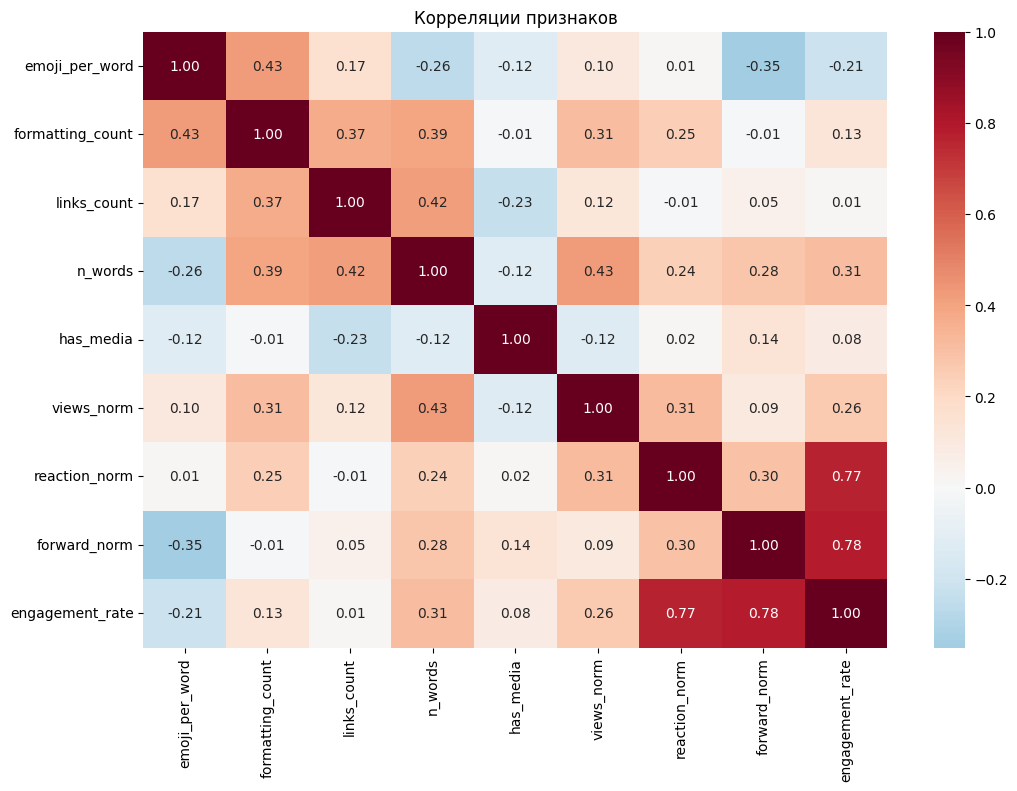

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "emoji_per_word",
    "formatting_count",
    "links_count",
    "n_words",
    "has_media"
]

targets = [
    "views_norm",
    "reaction_norm",
    "forward_norm",
    "engagement_rate"
]

corr_df = df[
    features + targets
].corr(method="spearman")

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("Корреляции признаков")
plt.show()

In [19]:
corr_df = df[features + targets].corr(method="spearman")
corr_df_rounded = corr_df.round(3)

print("\n=== CORRELATION MATRIX (SPEARMAN) ===\n")
print(corr_df_rounded.to_string())


=== CORRELATION MATRIX (SPEARMAN) ===

                  emoji_per_word  formatting_count  links_count  n_words  has_media  views_norm  reaction_norm  forward_norm  engagement_rate
emoji_per_word             1.000             0.425        0.165   -0.261     -0.118       0.104          0.013        -0.350           -0.210
formatting_count           0.425             1.000        0.368    0.391     -0.008       0.307          0.246        -0.011            0.132
links_count                0.165             0.368        1.000    0.418     -0.234       0.122         -0.009         0.051            0.015
n_words                   -0.261             0.391        0.418    1.000     -0.118       0.426          0.238         0.279            0.307
has_media                 -0.118            -0.008       -0.234   -0.118      1.000      -0.124          0.018         0.135            0.079
views_norm                 0.104             0.307        0.122    0.426     -0.124       1.000          0.3

Регрессия для каждой метрики

Просмотры

In [20]:
import statsmodels.formula.api as smf

formula = """
log_views_norm ~
emoji_per_word +
formatting_count +
links_count +
n_words +
has_media +
C(channel_username)
"""

model_views = smf.ols(
    formula=formula,
    data=df
).fit(cov_type="HC3")

print(model_views.summary())

                            OLS Regression Results                            
Dep. Variable:         log_views_norm   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     808.5
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:28:54   Log-Likelihood:                 11407.
No. Observations:               10420   AIC:                        -2.278e+04
Df Residuals:                   10405   BIC:                        -2.268e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Реакции

In [21]:
formula = """
log_reaction_norm ~
emoji_per_word +
formatting_count +
links_count +
n_words +
has_media +
C(channel_username)
"""

model_reactions = smf.ols(
    formula=formula,
    data=df
).fit(cov_type="HC3")

print(model_reactions.summary())

                            OLS Regression Results                            
Dep. Variable:      log_reaction_norm   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     292.8
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:29:05   Log-Likelihood:                 34318.
No. Observations:               10420   AIC:                        -6.861e+04
Df Residuals:                   10405   BIC:                        -6.850e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Репосты

In [22]:
formula = """
log_forward_norm ~
emoji_per_word +
formatting_count +
links_count +
n_words +
has_media +
C(channel_username)
"""

model_forwards = smf.ols(
    formula=formula,
    data=df
).fit(cov_type="HC3")

print(model_forwards.summary())

                            OLS Regression Results                            
Dep. Variable:       log_forward_norm   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     185.9
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:29:14   Log-Likelihood:                 38790.
No. Observations:               10420   AIC:                        -7.755e+04
Df Residuals:                   10405   BIC:                        -7.744e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Вовлеченность

In [23]:
formula = """
log_engagement_rate ~
emoji_per_word +
formatting_count +
links_count +
n_words +
has_media +
C(channel_username)
"""

model_eng = smf.ols(
    formula=formula,
    data=df
).fit(cov_type="HC3")

print(model_eng.summary())

                             OLS Regression Results                            
Dep. Variable:     log_engagement_rate   R-squared:                       0.651
Model:                             OLS   Adj. R-squared:                  0.650
Method:                  Least Squares   F-statistic:                     298.1
Date:                 Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                         20:29:18   Log-Likelihood:                 31876.
No. Observations:                10420   AIC:                        -6.372e+04
Df Residuals:                    10405   BIC:                        -6.361e+04
Df Model:                           14                                         
Covariance Type:                   HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

Таблица коэффициентов

In [24]:
models = {
    "views": model_views,
    "reactions": model_reactions,
    "forwards": model_forwards,
    "engagement": model_eng
}

results = []

for model_name, model in models.items():

    for feature in [
        "emoji_per_word",
        "formatting_count",
        "links_count",
        "n_words",
        "has_media"
    ]:

        results.append({
            "target": model_name,
            "feature": feature,
            "coef": model.params.get(feature),
            "p_value": model.pvalues.get(feature)
        })

results_df = pd.DataFrame(results)

print(results_df)

        target           feature      coef       p_value
0        views    emoji_per_word  0.043645  3.711393e-01
1        views  formatting_count  0.000730  1.056510e-05
2        views       links_count -0.000151  5.799345e-01
3        views           n_words -0.000049  1.391148e-03
4        views         has_media  0.008618  1.024501e-02
5    reactions    emoji_per_word  0.000714  9.046233e-01
6    reactions  formatting_count  0.000038  6.958818e-02
7    reactions       links_count -0.000213  4.699872e-11
8    reactions           n_words  0.000011  6.162284e-11
9    reactions         has_media  0.001988  1.000795e-09
10    forwards    emoji_per_word  0.006998  2.584542e-02
11    forwards  formatting_count  0.000068  1.453311e-06
12    forwards       links_count -0.000203  1.352765e-14
13    forwards           n_words  0.000008  1.763365e-11
14    forwards         has_media  0.003077  7.748984e-51
15  engagement    emoji_per_word  0.007696  2.721330e-01
16  engagement  formatting_coun

Сохранение

In [ ]:
output_path = "../data/dataset_cleaned.csv"
df.to_csv(output_path, index=False)

# Разобьем весь оригинальный датасет на логические блоки:
1. **Мета-информация** - данные о канале и посте
2. **Текстовые данные** - текст, очищенный текст, метрики текста, ссылки
3. **Вовлеченность** - просмотры, репосты, сумма реакций
4. **Реакции** - все отдельные реакции

In [ ]:
file_path = "../data/dataset_cleaned.csv" 
df = pd.read_csv(file_path)

Определяем группы колонок

In [29]:
# Мета-информация о посте и канале
meta_columns = [
    'channel_username', 
    'channel_title', 
    'channel_subscribers',
    'post_id', 
    'post_date', 
    'post_time', 
    'post_datetime', 
    'scraped_at',
    'is_scheduled', 
    'has_poll', 
    'has_media', 
    'media_type'
]

# Текстовые данные
text_columns = [
    'channel_username',
    'post_id',
    'text',           # оригинальный текст
    'text_clean',      # очищенный текст
    'text_length',           # длина оригинального текста
    'text_length_clean',     # длина очищенного текста
    'uppercase_count',        # количество заглавных букв
    'links_count_entities',
    'has_links_entities',
    'links_from_entities',
    'n_emojis',                # количество эмодзи
    'bold_count',              # количество жирного текста
    'italic_count',            # количество курсива
    'formatting_count',        # суммарное форматирование
    'n_words',                 # количество слов
    'emoji_per_word'           # эмодзи на слово
]

# Вовлеченность
engagement_columns = [
    'channel_username',
    'post_id',
    'views', 
    'forwards', 
    'total_reactions',
    # Нормализованные метрики
    'views_norm',              # просмотры / подписчики
    'reaction_norm',           # реакции / просмотры
    'forward_norm',            # репосты / просмотры
    'engagement_rate',         # (реакции+репосты) / просмотры
    # Логарифмические трансформации
    'log_views_norm',          # log(1 + views_norm)
    'log_reaction_norm',       # log(1 + reaction_norm)
    'log_forward_norm',        # log(1 + forward_norm)
    'log_engagement_rate'      # log(1 + engagement_rate)
]

# Реакции
reaction_columns = ['channel_username', 'post_id'] + [col for col in df.columns if col.startswith('reaction_')]


Проверяем существуют ли колонки

In [30]:
def get_existing_columns(columns, df_columns):
    """Возвращает только те колонки, которые есть в датафрейме."""
    return [col for col in columns if col in df_columns]

meta_cols_existing = get_existing_columns(meta_columns, df.columns)
text_cols_existing = get_existing_columns(text_columns, df.columns)
engagement_cols_existing = get_existing_columns(engagement_columns, df.columns)
reaction_cols_existing = get_existing_columns(reaction_columns, df.columns)

print(f"Мета-информация: {len(meta_cols_existing)} колонок")
print(f"Текстовые данные: {len(text_cols_existing)} колонок")
print(f"Вовлеченность: {len(engagement_cols_existing)} колонок")
print(f"Реакции: {len(reaction_cols_existing)} колонок")

Мета-информация: 12 колонок
Текстовые данные: 14 колонок
Вовлеченность: 13 колонок
Реакции: 66 колонок


Создаем отдельные датафреймы

In [31]:
df_meta = df[meta_cols_existing].copy()
df_text = df[text_cols_existing].copy()
df_engagement = df[engagement_cols_existing].copy()
df_reactions = df[reaction_cols_existing].copy()

Сохраняем

In [32]:
import os

output_dir = "../data/split/"

os.makedirs(output_dir, exist_ok=True)

df_meta.to_csv(f"{output_dir}01_meta.csv", index=False)
df_text.to_csv(f"{output_dir}02_text.csv", index=False)

df_engagement.to_csv(f"{output_dir}03_engagement.csv", index=False)
df_reactions.to_csv(f"{output_dir}04_reactions.csv", index=False)